# Linear Regression

Linear models and linear regression in particular are a powerful method of establishing relationships between variables and to make predictions about the behavior of a system based on one or more independent predictors. 

You have already applied linear regression in many contexts (e.g. as trend-lines in Excel). Here we will practice calculation, and plotting linear regression and correlations using the _scipy_ python package. 

We also introduce a new tool, the _statsmodel_ package that can be used to build more complex linear models, such as multiple linear regression. 

To make things a bit more simple, we are going back to the Palmer Archipelago Penguin dataset. This dataset has become a popular example dataset for environmental analysis, because it is comparatively simple to understand and has some nice features for analysis. (see e.g. [here](https://allisonhorst.github.io/palmerpenguins/articles/intro.html)).

The figure below shows the relationship between body mass and flipper length in the dataset: 

![](https://allisonhorst.github.io/palmerpenguins/articles/intro_files/figure-html/unnamed-chunk-14-1.png)

## Learning Goals

- Use *pandas* and *scipy* to calculate correlation coefficients
- Find linear model parameters such as slopes and offset
- Use the _statsmodel_ package to calculate multiple linear correlation and correlations involving *categorical* data
- Plot results of linear regression 

In [1]:
# We import all the packages that we need for this week's lab.  

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import statsmodels.formula.api as smf 
import statsmodels.api as sm 

## Loading the dataset

As before, we are loading the dataset into a _pandas_ dataframe. 

In [2]:
df_penguins = pd.read_csv('../../W4_Pandas_And_Environmental_Data/Data/palmer_penguin_data.csv',
                          sep = ',',
                          na_values='NA',
                          skiprows= 1,
                          index_col=0   # Use the first column as the index of the DataFrame
                          )
df_penguins

df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
rowid,,,,,,,,
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


As a reminder, the dataset contains measurements of several body features for 3 different Penguin species for several locations on the Antarctic Peninsula.  

In [4]:
df_penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


## Simple Linear Regression

For now, will focus on a single species, the _Adelie_ penguin. We extract these from the dataset: 

In [5]:
df_Adelie = df_penguins.loc[df_penguins.species == 'Adelie']
df_Adelie

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
rowid,,,,,,,,
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
148,Adelie,Dream,36.6,18.4,184.0,3475.0,female,2009
149,Adelie,Dream,36.0,17.8,195.0,3450.0,female,2009
150,Adelie,Dream,37.8,18.1,193.0,3750.0,male,2009


Let's create an example plot for these relationships. 

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

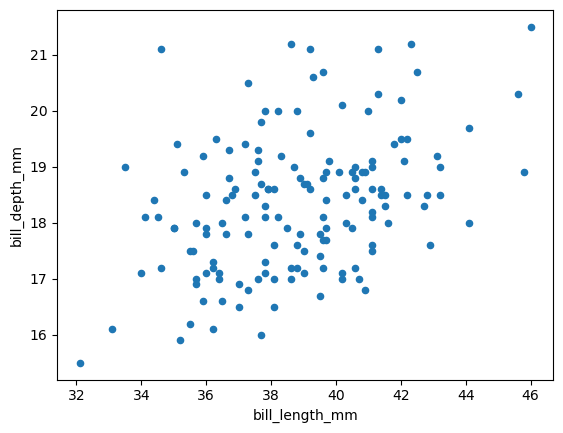

In [12]:
df_Adelie.plot(kind = 'scatter', x='bill_length_mm',y='bill_depth_mm')

### Linear correlation

Let's first use the Pearson correlation coefficient to see whether we can expect any linear relationships in the dataset. Since correlations only make sense for numeric values, we only apply this to the columns with numeric values (otherwise we will get an error). 

_pandas_ provides the [`.corr`-method](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) to do so directly on a data frame. 

`.corr(method='pearson', min_periods=1, numeric_only=False)`

As a default, this will omit any missing-values (`NaN`; `numeric_only=False`), and we can specify which correlation coefficient we want (the default is `pearson`).


In [13]:
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_Adelie[numeric_cols].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.391492,0.325785,0.548866
bill_depth_mm,0.391492,1.000000,0.307620,0.576138
flipper_length_mm,0.325785,0.307620,1.000000,0.468202
body_mass_g,0.548866,0.576138,0.468202,1.000000


The result is a correlation matrix, which shows the correlation coefficients between all variables. 

It looks as if there are some decent positive correlations between the variables in the dataset. However, _pandas_ does not provide additional information beyond the correlation coefficient. 

If we want to know more, we need to use the `scipy.stats`-package. To apply the package we need to manually remove any `NaN` values. 

In [14]:
import scipy.stats as stats 

df_without_nan = df_Adelie.copy().dropna()
x = df_without_nan['bill_length_mm']
y = df_without_nan['bill_depth_mm']

res = stats.pearsonr(x, y)
print(res)
print(res.confidence_interval(confidence_level=0.9))

PearsonRResult(statistic=np.float64(0.38581320049557943), pvalue=np.float64(1.514901409647618e-06))
ConfidenceInterval(low=np.float64(0.26299390690778335), high=np.float64(0.49632735805172123))


In addition to the correlation coefficient, we are now also getting a p-value and can extract a confidence interval for the estimated correlation. 

Note that the the correlation coefficient is slightly different from the value calculated by _pandas_. However, if we use the data set without missing values. They become the same

In [15]:
df_without_nan[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.385813,0.332274,0.544276
bill_depth_mm,0.385813,1.000000,0.310897,0.580156
flipper_length_mm,0.332274,0.310897,1.000000,0.464854
body_mass_g,0.544276,0.580156,0.464854,1.000000


## Linear regression

Let's find the linear regression line for this correlation. 

This can be done with [scipy.stats.linregress](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html). If we want to omit any nan, we can specify this as well. 

In [16]:
x = df_without_nan['bill_length_mm']
y = df_without_nan['bill_depth_mm']

res = stats.linregress(x,y,nan_policy='omit')
print(res)

LinregressResult(slope=np.float64(0.17668344293376226), intercept=np.float64(11.487707126154486), rvalue=np.float64(0.3858132004955793), pvalue=np.float64(1.5149014096476296e-06), stderr=np.float64(0.035207899073921585), intercept_stderr=np.float64(1.3700993275268667))


We are now getting quite a lot of information about the linear relationship, including `slope`, `y-offset`, `correlation coefficient` and `p-value`, as well as information about their confidence. 

We can use the `slope` and `intercept` to calculate estimated values for our dependent variable. 

In [17]:
bill_depth_mm_estimated = df_without_nan['bill_length_mm']*res.slope + res.intercept
bill_depth_mm_estimated

rowid
1      18.396030
2      18.466703
3      18.608050
5      17.971989
6      18.431366
         ...    
148    17.954321
149    17.848311
150    18.166341
151    17.848311
152    18.820070
Name: bill_length_mm, Length: 146, dtype: float64

Let's see how these compare by plotting them onto the original plot. 

Text(32, 21, 'y = 0.18x + 11.49\n$R^2$ = 0.15')

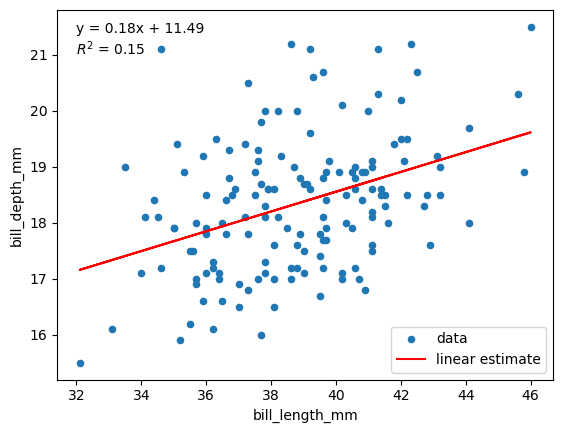

In [36]:
import matplotlib.pyplot as plt
df_Adelie.plot(kind = 'scatter', x='bill_length_mm',y='bill_depth_mm')
plt.plot( df_without_nan['bill_length_mm'], bill_depth_mm_estimated, 'r')
plt.legend(['data', 'linear estimate'])
plt.text(32,21, f'y = {res.slope:.2f}x + {res.intercept:.2f}\n$R^2$ = {(res.rvalue)**2:.2f}')

This gives us an idea about the residuals, we we can calculate as $res = y_{hat} - y$. 

For linear regression to be valid, these should be approximately normally distributed and not vary with respect to the underlying $x$ and $y$. 

Let's check that. 

In [22]:
residuals = bill_depth_mm_estimated - df_without_nan['bill_depth_mm'] 

PearsonRResult(statistic=np.float64(-1.942890293094024e-16), pvalue=np.float64(0.9999999999999986))


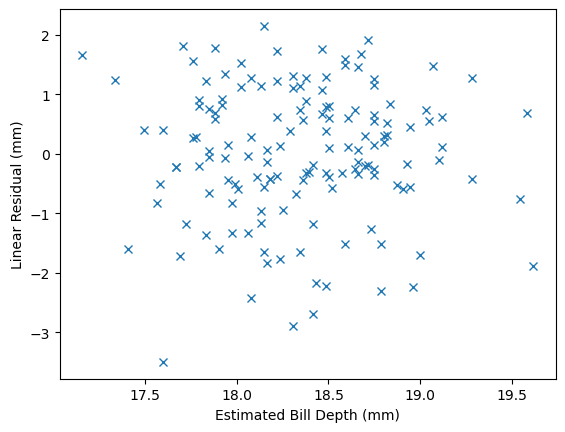

In [23]:
#residuals
plt.plot(bill_depth_mm_estimated, residuals,  'x')
plt.ylabel('Linear Residual (mm)')
plt.xlabel('Estimated Bill Depth (mm)')

print(stats.pearsonr(residuals,bill_depth_mm_estimated))

We can see that there is no significant relationship in the residuals, confirming the linear relationship. 

The histogram of residuals also looks OK. 

(array([ 1.,  3.,  6., 13.,  8., 35., 25., 25., 21.,  9.]),
 array([-3.49904575, -2.93427388, -2.36950201, -1.80473015, -1.23995828,
        -0.67518641, -0.11041454,  0.45435732,  1.01912919,  1.58390106,
         2.14867292]),
 <BarContainer object of 10 artists>)

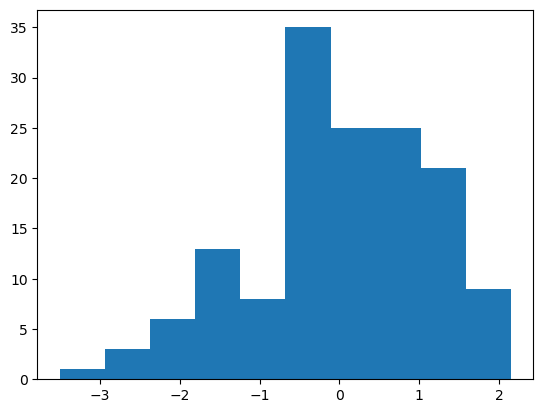

In [24]:
plt.hist(residuals)

## Multiple linear regression

We can expand linear regression to multiple variables. 

**Multiple linear regression**: This is an extension of simple linear regression where there are multiple independent variables. The model is expressed as $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$, where $\beta_0$ is the intercept and $\beta_i$ are the coefficients for each independent variable $x_i$.


Unlike simple linear regression, coefficients have to be estimated numerically by solving a system of linear equations. 

The `statsmodels`-package has an implementation for this. 

**Caveat:** This is a brief introduction to multiple linear regression. In general, you should be careful, when fitting multivariate models, because they might overfit your data and then not work well in practice. Because the model has to solved numerically, it also makes sense to transform all variables to be normally distributed and of the same magnitude. This technique is called normalization. 

In [28]:
# We drop all rows with missing values, because the linear regression function does not work with missing values.
df_Adelie = df_Adelie.dropna()

We can then implement the linear regression. 

We define the dependent variable $x$ and supply a matrix $X$ that contains all the independent variables. If we also want to add an offset, we can do this by adding a constant to $X$. 

Then `sm.OLS(y, X).fit()` will fit the model, and we can display the results `.summary()`.

In [ ]:
import statsmodels.formula.api as smf 
import statsmodels.api as sm 

y = df_Adelie['body_mass_g']
X = df_Adelie[['bill_length_mm','bill_depth_mm','flipper_length_mm']]
X = sm.add_constant(X) 
est = sm.OLS(y, X).fit() 
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.506
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     48.57
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.16e-21
Time:                        12:38:19   Log-Likelihood:                -1049.8
No. Observations:                 146   AIC:                             2108.
Df Residuals:                     142   BIC:                             2120.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -4270.6550    811.928     -5.260      0.000   -5875.683   -2665.627
bill_length_mm       54.5124     11.345      4.805      0.000      32.086      76.939
bill_depth_mm       144.1567     24.584      5.864      0.000      95.559     192.754
flipper_length_mm    16.9148      4.496      3.762      0.000       8.027      25.802
==============================================================================
Omnibus:                        2.005   Durbin-Watson:                   2.047
Prob(Omnibus):                  0.367   Jarque-Bera (JB):                1.735
Skew:                           0.265   Prob(JB):                        0.420
Kurtosis:                       3.062   Cond. No.                     5.88e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.88e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

You can see that a lot of information is provided. In our case, we are mostly interested in the model coefficients. 

The model is:

$ \text{body mass est} =  54.5124 \times \text{bill length} + 144.1567 \times \text{bill depth} + 16.9148 \times \text{flipper length} - 4270.6550 $

However, we are getting a warning that there is a high correlation between independent variables, which is not advised. So it would be better to test which variables are most correlated and remove these. 

There is another way to set this up, by specifying the model's independent and dependent variables like this:  

In [26]:
est = smf.ols(formula='body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm', data=df_Adelie).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     50.63
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.55e-22
Time:                        13:22:29   Log-Likelihood:                -1085.5
No. Observations:                 151   AIC:                             2179.
Df Residuals:                     147   BIC:                             2191.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -4341.3019    795.117     -5.460      0.000   -5912.639   -2769.964
bill_length_mm       55.3676     11.133      4.973      0.000      33.366      77.369
bill_depth_mm       140.8946     24.216      5.818      0.000      93.037     188.752
flipper_length_mm    17.4215      4.385      3.973      0.000       8.756      26.087
==============================================================================
Omnibus:                        1.762   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.414   Jarque-Bera (JB):                1.514
Skew:                           0.244   Prob(JB):                        0.469
Kurtosis:                       3.055   Cond. No.                     5.86e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.86e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

This is exactly the same as the first implementation, but provides more flexibility. 

### Feature engineering and discrete variables. 

If we suspect that we have features that are non-linear (for example quadratic) or if we want to test the effect of discrete variables (e.g. `sex`). We can also implement this as a linear model. 

For example, we are creating a new column in our data frame that encodes the `sex` as an ordinal variable. 

In [34]:
df_Adelie['sex_ord'] = pd.Categorical(df_Adelie['sex']) 
df_Adelie

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,sex_ord
rowid,,,,,,,,,
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,male
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,female
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,female
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,female
6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,male
...,...,...,...,...,...,...,...,...,...
148,Adelie,Dream,36.6,18.4,184.0,3475.0,female,2009,female
149,Adelie,Dream,36.0,17.8,195.0,3450.0,female,2009,female
150,Adelie,Dream,37.8,18.1,193.0,3750.0,male,2009,male


In [35]:
est = smf.ols(formula='body_mass_g ~ bill_length_mm + bill_depth_mm + sex_ord', data=df_Adelie).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     68.34
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           2.07e-27
Time:                        13:26:02   Log-Likelihood:                -1036.2
No. Observations:                 146   AIC:                             2080.
Df Residuals:                     142   BIC:                             2092.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         984.4166    601.200      1.637      0.104    -204.042    2172.875
sex_ord[T.male]   476.6000     69.999      6.809      0.000     338.224     614.976
bill_length_mm     26.8589     11.471      2.342      0.021       4.184      49.534
bill_depth_mm      78.5228     25.199      3.116      0.002      28.709     128.337
==============================================================================
Omnibus:                        0.550   Durbin-Watson:                   1.928
Prob(Omnibus):                  0.760   Jarque-Bera (JB):                0.693
Skew:                           0.093   Prob(JB):                        0.707
Kurtosis:                       2.718   Cond. No.                     1.06e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.06e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Our model now includes the effect of `sex`, showing that there is a positive correlation with `male` and weight. 